# NLP Project 9: Student Feedback Analysis

**Dataset:** Contextual Sentiment Feedback Dataset (Kaggle)

This notebook analyzes university student feedback to:
- preprocess feedback text,
- classify positive, neutral and negative sentiment,
- identify common student concerns,
- compare machine-learning models,
- generate improvement-oriented insights.


In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [
        LEMMATIZER.lemmatize(w)
        for w in words
        if w not in STOP_WORDS and len(w) > 2
    ]
    return " ".join(words)

def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, pred, average="weighted", zero_division=0)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(f"Weighted Precision: {precision*100:.2f}%")
    print(f"Weighted Recall: {recall*100:.2f}%")
    print(f"Weighted F1-score: {f1*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, pred, zero_division=0))
    return pred, acc, precision, recall, f1


## 1. Download the Dataset

In [3]:
path = kagglehub.dataset_download("ziya07/contextual-sentiment-feedback-dataset")
print("Dataset path:", path)
print("Files:", os.listdir(path))

100%|██████████| 54.7k/54.7k [00:00<00:00, 10.4MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/ziya07/contextual-sentiment-feedback-dataset/versions/1
Files: ['student_feedback_dataset.csv']


## 2. Load the Dataset

In [4]:
csv_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print("CSV files found:", csv_files)

df = pd.read_csv(csv_files[0])
print("Shape:", df.shape)
df.head()

CSV files found: ['/root/.cache/kagglehub/datasets/ziya07/contextual-sentiment-feedback-dataset/versions/1/student_feedback_dataset.csv']
Shape: (1223, 11)


,student_id,department,subject_name,feedback_text,preprocessed_text,sentiment_label,sarcasm_flag,emotion_tag,feedback_type,subject_specific_context,response_required
0,STU0001,CIVIL,Concrete Tech,Attack medical dog technology top several insi...,attack medical dog technology top several insi...,negative,0,anger,Infrastructure,Project-Based,1
1,STU0002,CIVIL,Concrete Tech,Wait worry speak program child past beautiful ...,wait worry speak program child past beautiful ...,positive,0,anger,Infrastructure,Lab-Intensive,0
2,STU0003,BIO,Genetics,Bank those report box your treatment accept in...,bank those report box your treatment accept in...,neutral,0,sadness,Academic,Project-Based,1
3,STU0004,ME,Fluid Mechanics,Can character million listen right amount ask ...,can character million listen right amount ask ...,positive,0,joy,Academic,Theory-Heavy,0
4,STU0005,ME,Fluid Mechanics,Good cost political street dream finish figure.,good cost political street dream finish figure,negative,0,surprise,Academic,Theory-Heavy,1


## 3. Inspect and Clean the Data

In [5]:
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

['student_id', 'department', 'subject_name', 'feedback_text', 'preprocessed_text', 'sentiment_label', 'sarcasm_flag', 'emotion_tag', 'feedback_type', 'subject_specific_context', 'response_required']

Missing values:
student_id                  0
department                  0
subject_name                0
feedback_text               0
preprocessed_text           0
sentiment_label             0
sarcasm_flag                0
emotion_tag                 0
feedback_type               0
subject_specific_context    0
response_required           0
dtype: int64

Duplicates: 0


In [6]:
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

df = df.dropna(subset=["feedback_text", "sentiment_label"]).copy()
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)
print(df["sentiment_label"].value_counts())

Shape after cleaning: (1223, 11)
sentiment_label
positive    489
neutral     368
negative    366
Name: count, dtype: int64


## 4. Sentiment Distribution

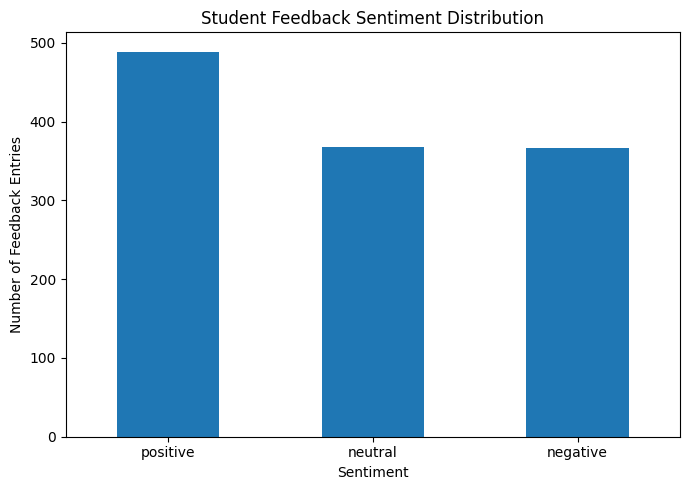

In [7]:
plt.figure(figsize=(7, 5))
df["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Student Feedback Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback Entries")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Text Preprocessing

In [8]:
df["clean_feedback"] = df["feedback_text"].apply(preprocess_text)
df[["feedback_text", "clean_feedback", "sentiment_label"]].head()

,feedback_text,clean_feedback,sentiment_label
0,Attack medical dog technology top several insi...,attack medical dog technology top several insi...,negative
1,Wait worry speak program child past beautiful ...,wait worry speak program child past beautiful ...,positive
2,Bank those report box your treatment accept in...,bank report box treatment accept interesting p...,neutral
3,Can character million listen right amount ask ...,character million listen right amount ask scor...,positive
4,Good cost political street dream finish figure.,good cost political street dream finish figure,negative


## 6. Common Student Concerns

,Term,Frequency
0,catch,14
1,natural,12
2,reach,11
3,see,11
4,success,10
5,think,10
6,agreement,10
7,alone,10
8,raise,10
9,suggest,10


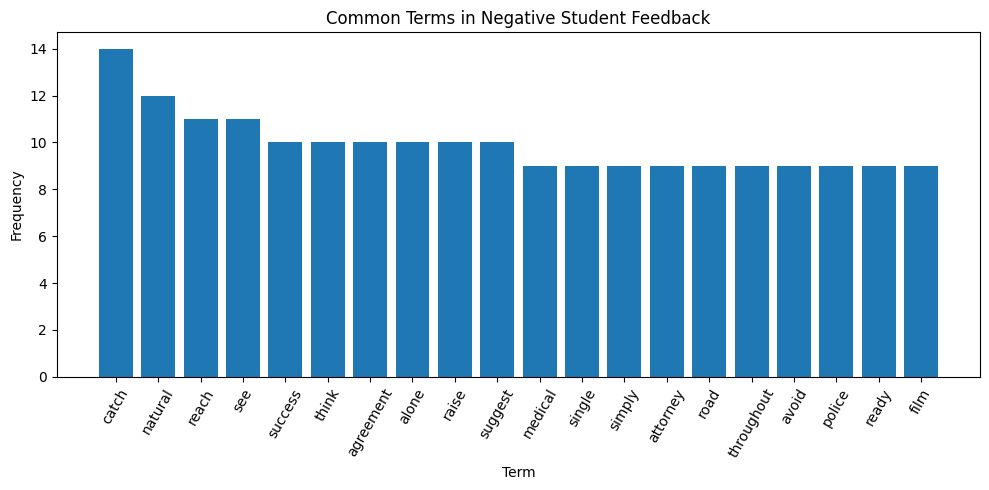

In [9]:
negative_feedback = df[
    df["sentiment_label"].astype(str).str.lower() == "negative"
]["clean_feedback"]

negative_words = " ".join(negative_feedback).split()
concern_counts = Counter(negative_words)

concerns = pd.DataFrame(
    concern_counts.most_common(20),
    columns=["Term", "Frequency"]
)

display(concerns)

plt.figure(figsize=(10, 5))
plt.bar(concerns["Term"], concerns["Frequency"])
plt.title("Common Terms in Negative Student Feedback")
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## 7. Feedback by Department and Type

In [10]:
if "department" in df.columns:
    display(pd.crosstab(df["department"], df["sentiment_label"]))

if "feedback_type" in df.columns:
    display(pd.crosstab(df["feedback_type"], df["sentiment_label"]))

sentiment_label,negative,neutral,positive
department,,,
BIO,57,50,78
CIVIL,55,49,77
CS,55,54,68
ECE,56,63,68
ENG,53,35,74
MBA,39,61,62
ME,51,56,62


sentiment_label,negative,neutral,positive
feedback_type,,,
Academic,115,117,142
Infrastructure,135,123,173
Instructor,116,128,174


## 8. TF-IDF Feature Extraction

In [11]:
X_text = df["clean_feedback"]
y = df["sentiment_label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=8000,
    ngram_range=(1, 2),
    min_df=1
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Training matrix:", X_train.shape)
print("Testing matrix:", X_test.shape)

Training matrix: (978, 8000)
Testing matrix: (245, 8000)


## 9. Multinomial Naive Bayes

In [12]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred, nb_acc, nb_prec, nb_rec, nb_f1 = evaluate_model(
    "Multinomial Naive Bayes", nb_model, X_test, y_test
)

Multinomial Naive Bayes Accuracy: 38.37%
Weighted Precision: 35.00%
Weighted Recall: 38.37%
Weighted F1-score: 27.77%

Classification Report:
              precision    recall  f1-score   support

    negative       0.28      0.07      0.11        73
     neutral       0.36      0.05      0.09        74
    positive       0.39      0.87      0.54        98

    accuracy                           0.38       245
   macro avg       0.34      0.33      0.25       245
weighted avg       0.35      0.38      0.28       245



## 10. Logistic Regression

In [13]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred, lr_acc, lr_prec, lr_rec, lr_f1 = evaluate_model(
    "Logistic Regression", lr_model, X_test, y_test
)

Logistic Regression Accuracy: 38.37%
Weighted Precision: 37.25%
Weighted Recall: 38.37%
Weighted F1-score: 36.04%

Classification Report:
              precision    recall  f1-score   support

    negative       0.28      0.18      0.22        73
     neutral       0.43      0.27      0.33        74
    positive       0.40      0.62      0.49        98

    accuracy                           0.38       245
   macro avg       0.37      0.36      0.35       245
weighted avg       0.37      0.38      0.36       245



## 11. GridSearchCV

In [14]:
param_grid = {"alpha": [0.1, 0.5, 1.0]}
grid = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV weighted F1:", round(grid.best_score_, 4))

best_nb = grid.best_estimator_
grid_pred, grid_acc, grid_prec, grid_rec, grid_f1 = evaluate_model(
    "Tuned Multinomial Naive Bayes", best_nb, X_test, y_test
)

Best parameters: {'alpha': 0.1}
Best CV weighted F1: 0.3413
Tuned Multinomial Naive Bayes Accuracy: 40.41%
Weighted Precision: 38.74%
Weighted Recall: 40.41%
Weighted F1-score: 37.62%

Classification Report:
              precision    recall  f1-score   support

    negative       0.29      0.16      0.21        73
     neutral       0.43      0.30      0.35        74
    positive       0.42      0.66      0.52        98

    accuracy                           0.40       245
   macro avg       0.38      0.37      0.36       245
weighted avg       0.39      0.40      0.38       245



## 12. Model Comparison

,Model,Accuracy (%),Weighted F1 (%)
0,Multinomial NB,38.37,27.77
1,Logistic Regression,38.37,36.04
2,Tuned Multinomial NB,40.41,37.62


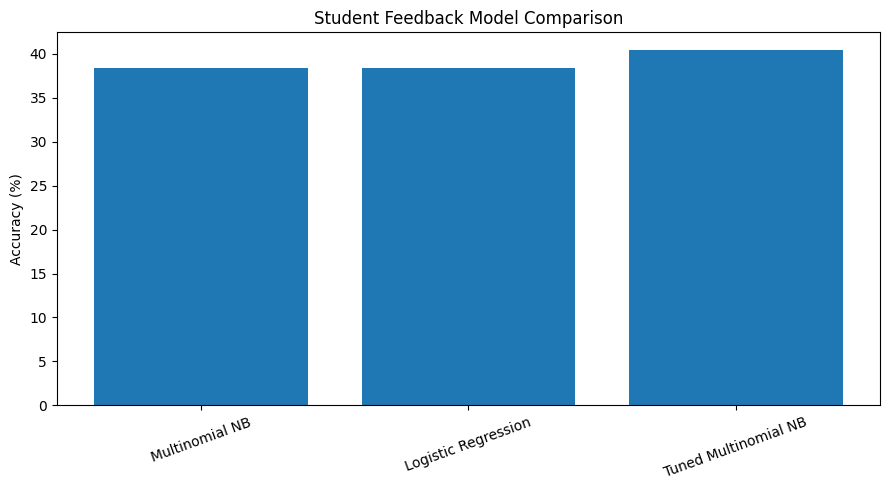

In [15]:
comparison = pd.DataFrame({
    "Model": ["Multinomial NB", "Logistic Regression", "Tuned Multinomial NB"],
    "Accuracy (%)": [nb_acc*100, lr_acc*100, grid_acc*100],
    "Weighted F1 (%)": [nb_f1*100, lr_f1*100, grid_f1*100]
})

display(comparison.round(2))

plt.figure(figsize=(9, 5))
plt.bar(comparison["Model"], comparison["Accuracy (%)"])
plt.ylabel("Accuracy (%)")
plt.title("Student Feedback Model Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 13. Confusion Matrix

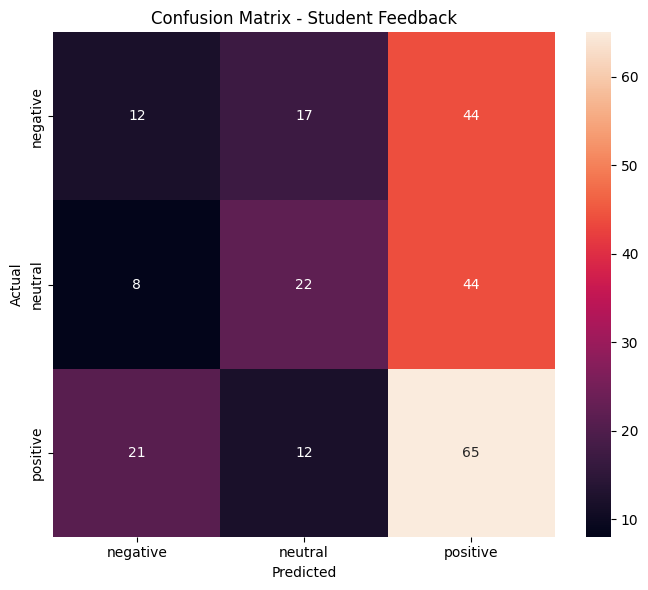

In [16]:
cm = confusion_matrix(y_test, grid_pred, labels=best_nb.classes_)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=best_nb.classes_,
    yticklabels=best_nb.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Student Feedback")
plt.tight_layout()
plt.show()

## 14. Custom Student Feedback Prediction

In [17]:
def predict_student_sentiment(text):
    cleaned = preprocess_text(text)
    vector = vectorizer.transform([cleaned])
    return best_nb.predict(vector)[0]

print(predict_student_sentiment("The instructor explains concepts clearly and the classes are very useful."))
print(predict_student_sentiment("The course is difficult to follow and the teaching method needs improvement."))

neutral
positive


## 15. Improvement Suggestions

In [18]:
print("Improvement-oriented findings")
print("-----------------------------")
print("Most common sentiment:", df["sentiment_label"].value_counts().idxmax())
print("Common negative-feedback terms:", ", ".join(concerns.head(10)["Term"]))

if "subject_name" in df.columns:
    print("\nSentiment by subject:")
    display(pd.crosstab(df["subject_name"], df["sentiment_label"]))

if "response_required" in df.columns:
    print("\nFeedback requiring response:")
    display(df["response_required"].value_counts(dropna=False))

Improvement-oriented findings
-----------------------------
Most common sentiment: positive
Common negative-feedback terms: catch, natural, reach, see, success, think, agreement, alone, raise, suggest

Sentiment by subject:


sentiment_label,negative,neutral,positive
subject_name,,,
AI,21,16,23
Concrete Tech,26,25,40
Cybersecurity,18,19,17
Data Structures,16,19,28
Digital Circuits,25,25,36
Embedded Systems,31,38,32
Finance,23,29,30
Fluid Mechanics,30,37,33
Genetics,25,30,42



Feedback requiring response:


,count
response_required,
1,819
0,404


## 16. Conclusion

The notebook applies NLP preprocessing, TF-IDF vectorization and machine-learning classification to student feedback. Sentiment patterns and frequent negative terms are used to identify common concerns and support improvement suggestions for teaching, subjects and academic services.

**Important:** Evaluation metrics are generated from the actual execution of the notebook and are not manually fabricated.